# Blind Assistant Glass - YOLO11n Object Detection

**Pipeline:** Download → Audit → Convert to YOLO format → Distribution
analysis → Train YOLO11n → Evaluate → Export for edge deployment.


## 1. Setup


In [15]:
!pip install -q ultralytics opencv-python-headless pyyaml pandas matplotlib

import os, sys, glob, json, shutil, random, zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import yaml
import torch

random.seed(42)
np.random.seed(42)

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
!nvidia-smi -L 2>/dev/null || echo "No GPU detected — go to Runtime > Change runtime type > GPU"


Torch: 2.11.0+cu128 | CUDA available: True
GPU 0: Tesla T4 (UUID: GPU-4a86531c-d053-4866-571e-17e826bd59c2)


## 2. Download the dataset




In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(RAW_DIR)

print("Dataset extracted to:", RAW_DIR)

## 3. Dataset audit

Walks every file, reports counts by type, and guesses whether the labels are
already in YOLO `.txt` format, Pascal VOC `.xml`, or COCO `.json`.


In [17]:
def walk_summary(root):
    ext_counter = Counter()
    all_files = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            p = Path(dirpath) / fn
            ext_counter[p.suffix.lower()] += 1
            all_files.append(p)
    print(f"Total files under {root}: {len(all_files)}")
    print("\nFile types:")
    for ext, n in ext_counter.most_common():
        print(f"  {ext or '(no ext)'}: {n}")
    return all_files

all_files = walk_summary(RAW_DIR)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
image_files = [p for p in all_files if p.suffix.lower() in IMAGE_EXTS]
txt_files   = [p for p in all_files if p.suffix.lower() == ".txt" and p.name.lower() not in {"classes.txt", "readme.txt"}]
xml_files   = [p for p in all_files if p.suffix.lower() == ".xml"]
json_files  = [p for p in all_files if p.suffix.lower() == ".json"]
yaml_files  = [p for p in all_files if p.suffix.lower() in {".yaml", ".yml"}]
names_files = [p for p in all_files if p.name.lower() in {"classes.txt", "obj.names"}]

print(f"\nImages: {len(image_files)}")
print(f"Possible YOLO .txt labels: {len(txt_files)}")
print(f"Possible Pascal VOC .xml labels: {len(xml_files)}")
print(f"Possible COCO .json labels: {len(json_files)}")
print(f"yaml files found: {[str(p) for p in yaml_files]}")
print(f"class-name files found: {[str(p) for p in names_files]}")

if len(txt_files) >= max(1, int(len(image_files) * 0.5)):
    ANNOTATION_FORMAT = "yolo"
elif len(xml_files) >= max(1, int(len(image_files) * 0.5)):
    ANNOTATION_FORMAT = "voc"
elif len(json_files) > 0:
    ANNOTATION_FORMAT = "coco"
else:
    ANNOTATION_FORMAT = "unknown"

print(f"\nDetected annotation format: {ANNOTATION_FORMAT.upper()}")

def common_dir(paths):
    return Counter(str(p.parent) for p in paths).most_common(1)[0][0] if paths else None

IMAGES_DIR = common_dir(image_files)
if ANNOTATION_FORMAT == "yolo":
    LABELS_DIR = common_dir(txt_files)
elif ANNOTATION_FORMAT == "voc":
    LABELS_DIR = common_dir(xml_files)
elif ANNOTATION_FORMAT == "coco":
    LABELS_DIR = str(json_files[0]) if json_files else None
else:
    LABELS_DIR = None

print("\nMost likely images folder:", IMAGES_DIR)
print("Most likely labels location:", LABELS_DIR)

print("\nSample files (up to 15):")
for p in all_files[:15]:
    print(" ", p)


Total files under /content/raw_dataset: 16222

File types:
  .jpg: 8114
  .txt: 8107
  .yaml: 1

Images: 8114
Possible YOLO .txt labels: 8107
Possible Pascal VOC .xml labels: 0
Possible COCO .json labels: 0
yaml files found: ['/content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/data.yaml']
class-name files found: []

Detected annotation format: YOLO

Most likely images folder: /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/train/images
Most likely labels location: /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/train/labels

Sample files (up to 15):
  /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/data.yaml
  /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv

In [18]:
# ------------------------------------------------------------------
# EDIT ONLY IF the auto-detected values above are wrong for this dataset
# ------------------------------------------------------------------
# IMAGES_DIR = "/content/raw_dataset/.../images"
# LABELS_DIR = "/content/raw_dataset/.../labels"
# ANNOTATION_FORMAT = "yolo"   # "yolo" | "voc" | "coco"

print("Using:")
print("  IMAGES_DIR        =", IMAGES_DIR)
print("  LABELS_DIR         =", LABELS_DIR)
print("  ANNOTATION_FORMAT  =", ANNOTATION_FORMAT)


Using:
  IMAGES_DIR        = /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/train/images
  LABELS_DIR         = /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/train/labels
  ANNOTATION_FORMAT  = yolo


### Class names

Tries a shipped `data.yaml` / `classes.txt` first. If the dataset has neither,
it falls back to generic `class_0, class_1, ...` names read off the YOLO label
files — in that case, rename `CLASS_NAMES` yourself based on what the dataset
actually contains (check the dataset's README/paper on the Mendeley page).


In [19]:
CLASS_NAMES = None

for yf in yaml_files:
    try:
        with open(yf) as f:
            y = yaml.safe_load(f)
        if isinstance(y, dict) and "names" in y:
            names = y["names"]
            CLASS_NAMES = list(names.values()) if isinstance(names, dict) else list(names)
            print(f"Loaded class names from {yf}: {CLASS_NAMES}")
            break
    except Exception:
        pass

if CLASS_NAMES is None and names_files:
    with open(names_files[0]) as f:
        CLASS_NAMES = [l.strip() for l in f if l.strip()]
    print(f"Loaded class names from {names_files[0]}: {CLASS_NAMES}")

if CLASS_NAMES is None and ANNOTATION_FORMAT == "yolo" and txt_files:
    ids = set()
    for p in txt_files:
        try:
            with open(p) as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        ids.add(int(parts[0]))
        except Exception:
            pass
    CLASS_NAMES = [f"class_{i}" for i in sorted(ids)]
    print("No class-name file found. Placeholder names generated:", CLASS_NAMES)
    print(">>> Rename CLASS_NAMES below to the real object names for this dataset <<<")

# CLASS_NAMES = ["person", "door", "chair", ...]   # <- override manually if needed

print("\nFinal CLASS_NAMES:", CLASS_NAMES)


Loaded class names from /content/raw_dataset/Object Detection Dataset  Navigation Assistance for the Visually Impaired People using YOLOv11/data.yaml: ['Bin', 'Building Pillar', 'Bus', 'CNG', 'Car', 'Cycle', 'Electric Pole', 'Food Van', 'Food cart', 'Footpath', 'Leguna', 'Motorcycle', 'Obstacle', 'Parking Cone', 'Person', 'Pickup', 'Rickshaw', 'Stairs', 'Tree', 'Truck', 'Van', 'Van gari']

Final CLASS_NAMES: ['Bin', 'Building Pillar', 'Bus', 'CNG', 'Car', 'Cycle', 'Electric Pole', 'Food Van', 'Food cart', 'Footpath', 'Leguna', 'Motorcycle', 'Obstacle', 'Parking Cone', 'Person', 'Pickup', 'Rickshaw', 'Stairs', 'Tree', 'Truck', 'Van', 'Van gari']


## 4. Preprocess: build a clean YOLO-format dataset

Copies every image into `images/{train,val,test}`, converts labels to YOLO
`.txt` (from VOC/COCO if needed), drops corrupt images, and keeps images with
no annotation as background (empty label file) rather than discarding them.


In [20]:
YOLO_ROOT = "/content/dataset_yolo"
IMG_OUT = Path(YOLO_ROOT, "images")
LBL_OUT = Path(YOLO_ROOT, "labels")
for split in ["train", "val", "test"]:
    (IMG_OUT / split).mkdir(parents=True, exist_ok=True)
    (LBL_OUT / split).mkdir(parents=True, exist_ok=True)

def voc_to_yolo_lines(xml_path, class_names):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    lines = []
    for obj in root.findall("object"):
        cls = obj.find("name").text
        if cls not in class_names:
            class_names.append(cls)
        cid = class_names.index(cls)
        b = obj.find("bndbox")
        xmin, ymin, xmax, ymax = [float(b.find(t).text) for t in ("xmin", "ymin", "xmax", "ymax")]
        xc, yc = (xmin + xmax) / 2 / w, (ymin + ymax) / 2 / h
        bw, bh = (xmax - xmin) / w, (ymax - ymin) / h
        lines.append(f"{cid} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return lines

def coco_to_yolo(json_path):
    with open(json_path) as f:
        coco = json.load(f)
    cats = sorted(coco["categories"], key=lambda c: c["id"])
    names = [c["name"] for c in cats]
    id_map = {c["id"]: i for i, c in enumerate(cats)}
    img_info = {im["id"]: im for im in coco["images"]}
    ann_by_img = defaultdict(list)
    for ann in coco["annotations"]:
        im = img_info[ann["image_id"]]
        w, h = im["width"], im["height"]
        x, y, bw, bh = ann["bbox"]
        xc, yc = (x + bw / 2) / w, (y + bh / 2) / h
        bw, bh = bw / w, bh / h
        cid = id_map[ann["category_id"]]
        ann_by_img[im["file_name"]].append(f"{cid} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return names, ann_by_img

image_files = sorted([p for p in Path(IMAGES_DIR).rglob("*") if p.suffix.lower() in IMAGE_EXTS])
random.shuffle(image_files)

n = len(image_files)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
split_of = {}
for i, p in enumerate(image_files):
    split_of[p] = "train" if i < n_train else ("val" if i < n_train + n_val else "test")

print(f"Total images: {n} -> train {n_train}, val {n_val}, test {n - n_train - n_val}")

coco_names, coco_ann = (None, None)
if ANNOTATION_FORMAT == "coco":
    coco_names, coco_ann = coco_to_yolo(LABELS_DIR)
    if not CLASS_NAMES:
        CLASS_NAMES = coco_names

n_corrupt, n_background = 0, 0

for img_path in image_files:
    split = split_of[img_path]
    try:
        with Image.open(img_path) as im:
            im.verify()
    except Exception:
        n_corrupt += 1
        continue

    shutil.copy(img_path, IMG_OUT / split / img_path.name)
    stem = img_path.stem
    lines = []

    if ANNOTATION_FORMAT == "yolo":
        src = Path(LABELS_DIR) / f"{stem}.txt"
        if src.exists():
            lines = [l for l in src.read_text().splitlines() if l.strip()]
        else:
            n_background += 1
    elif ANNOTATION_FORMAT == "voc":
        src = Path(LABELS_DIR) / f"{stem}.xml"
        if src.exists():
            lines = voc_to_yolo_lines(src, CLASS_NAMES)
        else:
            n_background += 1
    elif ANNOTATION_FORMAT == "coco":
        lines = coco_ann.get(img_path.name, [])
        if not lines:
            n_background += 1

    (LBL_OUT / split / f"{stem}.txt").write_text("\n".join(lines))

print(f"Corrupt images skipped: {n_corrupt}")
print(f"Images with no annotation (kept as background): {n_background}")


Total images: 7023 -> train 5618, val 702, test 703
Corrupt images skipped: 0
Images with no annotation (kept as background): 0


In [21]:
data_yaml = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
DATA_YAML_PATH = f"{YOLO_ROOT}/data.yaml"
with open(DATA_YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(DATA_YAML_PATH).read())


path: /content/dataset_yolo
train: images/train
val: images/val
test: images/test
names:
  0: Bin
  1: Building Pillar
  2: Bus
  3: CNG
  4: Car
  5: Cycle
  6: Electric Pole
  7: Food Van
  8: Food cart
  9: Footpath
  10: Leguna
  11: Motorcycle
  12: Obstacle
  13: Parking Cone
  14: Person
  15: Pickup
  16: Rickshaw
  17: Stairs
  18: Tree
  19: Truck
  20: Van
  21: Van gari



## 5. Distribution analysis


In [25]:
def load_split_stats(split):
    rows = []
    bad_labels = []

    for lbl_file in (LBL_OUT / split).glob("*.txt"):
        lines = [l for l in lbl_file.read_text().splitlines() if l.strip()]

        if not lines:
            rows.append({
                "split": split,
                "class_id": -1,
                "bw": None,
                "bh": None,
                "image": lbl_file.stem
            })
            continue

        for line_num, line in enumerate(lines, start=1):
            parts = line.split()

            if len(parts) != 5:
                bad_labels.append({
                    "split": split,
                    "file": lbl_file.name,
                    "line": line_num,
                    "values": len(parts),
                    "content": line
                })
                continue

            try:
                cid, xc, yc, bw, bh = parts

                rows.append({
                    "split": split,
                    "class_id": int(cid),
                    "bw": float(bw),
                    "bh": float(bh),
                    "image": lbl_file.stem
                })

            except ValueError:
                bad_labels.append({
                    "split": split,
                    "file": lbl_file.name,
                    "line": line_num,
                    "values": len(parts),
                    "content": line
                })

    return rows, bad_labels


rows = []
bad_labels = []

for split in ["train", "val", "test"]:
    split_rows, split_bad = load_split_stats(split)
    rows.extend(split_rows)
    bad_labels.extend(split_bad)

df = pd.DataFrame(rows)

print("Unique images per split:")
print(df.groupby("split")["image"].nunique())

if bad_labels:
    print(f"\nWARNING: {len(bad_labels)} malformed label lines found.")
    display(pd.DataFrame(bad_labels).head(20))
else:
    print("\nAll YOLO labels are valid.")

Unique images per split:
split
test     1
train    8
Name: image, dtype: int64



,split,file,line,values,content
0,train,frame_70s_jpg.rf.036ca7de8baf02cffd524f36ae44c...,1,51,21 0.1268518515625 0.49010416718750005 0.13148...
1,train,frame_70s_jpg.rf.036ca7de8baf02cffd524f36ae44c...,2,49,14 0.0648148140625 0.5 0.059259259375 0.505208...
2,train,frame_70s_jpg.rf.036ca7de8baf02cffd524f36ae44c...,3,131,11 0.440740740625 0.5244791671875 0.4388888890...
3,train,frame_70s_jpg.rf.036ca7de8baf02cffd524f36ae44c...,4,101,16 0.6981481484375001 0.4739583328125 0.700925...
4,train,frame_70s_jpg.rf.036ca7de8baf02cffd524f36ae44c...,5,69,4 0.7166666671875 0.7171875 0.7138888890625 0....
5,train,frame_368s_jpg.rf.9aa9b3f9f40869fdb118dc9a0836...,1,157,2 0.49436307343749997 0 0.2758786640625 0.1334...
6,train,frame_368s_jpg.rf.9aa9b3f9f40869fdb118dc9a0836...,2,99,14 0 0.5305813078125 0.019595328125 0.69017245...
7,train,frame_17s_jpg.rf.ec98e3c5f9d943fcb295e4bd15a06...,1,109,16 0.615150240625 0.5210857328125 0.6194736843...
8,train,frame_17s_jpg.rf.ec98e3c5f9d943fcb295e4bd15a06...,2,45,4 0 0.5130929609375 0.00043990781249999997 0.5...
9,train,frame_17s_jpg.rf.ec98e3c5f9d943fcb295e4bd15a06...,3,65,11 0.2964894390625 0.473635621875 0.2992906687...


### Visual sanity check — a few labeled images


[SKIP] frame_97s_jpg.rf.c59da828f3cc4b572603bc1ed4ef0bf1.txt | line 1 | found 231 values
        16 0.625 0.5595703125 0.628472221875 0.5576171875 0.628472221875 0.5419921875 0.6319444437499999 0.5400390625 0.6319444437499999 0.4970703125 0.6354166671875 0.4951171875 0.6354166671875 0.4853515625 0.625 0.4814453125 0.6319444437499999 0.4716796875 0.625 0.4658203125 0.625 0.4580078125 0.621527778125 0.4541015625 0.6145833328125 0.4521484375 0.6111111109375 0.4404296875 0.6006944437499999 0.4345703125 0.6006944437499999 0.4248046875 0.6076388890625 0.4130859375 0.6076388890625 0.4072265625 0.6041666671875 0.4052734375 0.6076388890625 0.4013671875 0.6076388890625 0.3837890625 0.6111111109375 0.3818359375 0.6111111109375 0.3779296875 0.6041666671875 0.3720703125 0.6076388890625 0.3701171875 0.6111111109375 0.3427734375 0.6145833328125 0.3408203125 0.6111111109375 0.3388671875 0.6145833328125 0.3369140625 0.6145833328125 0.3310546875 0.6111111109375 0.3291015625 0.6145833328125 0.3232421875 

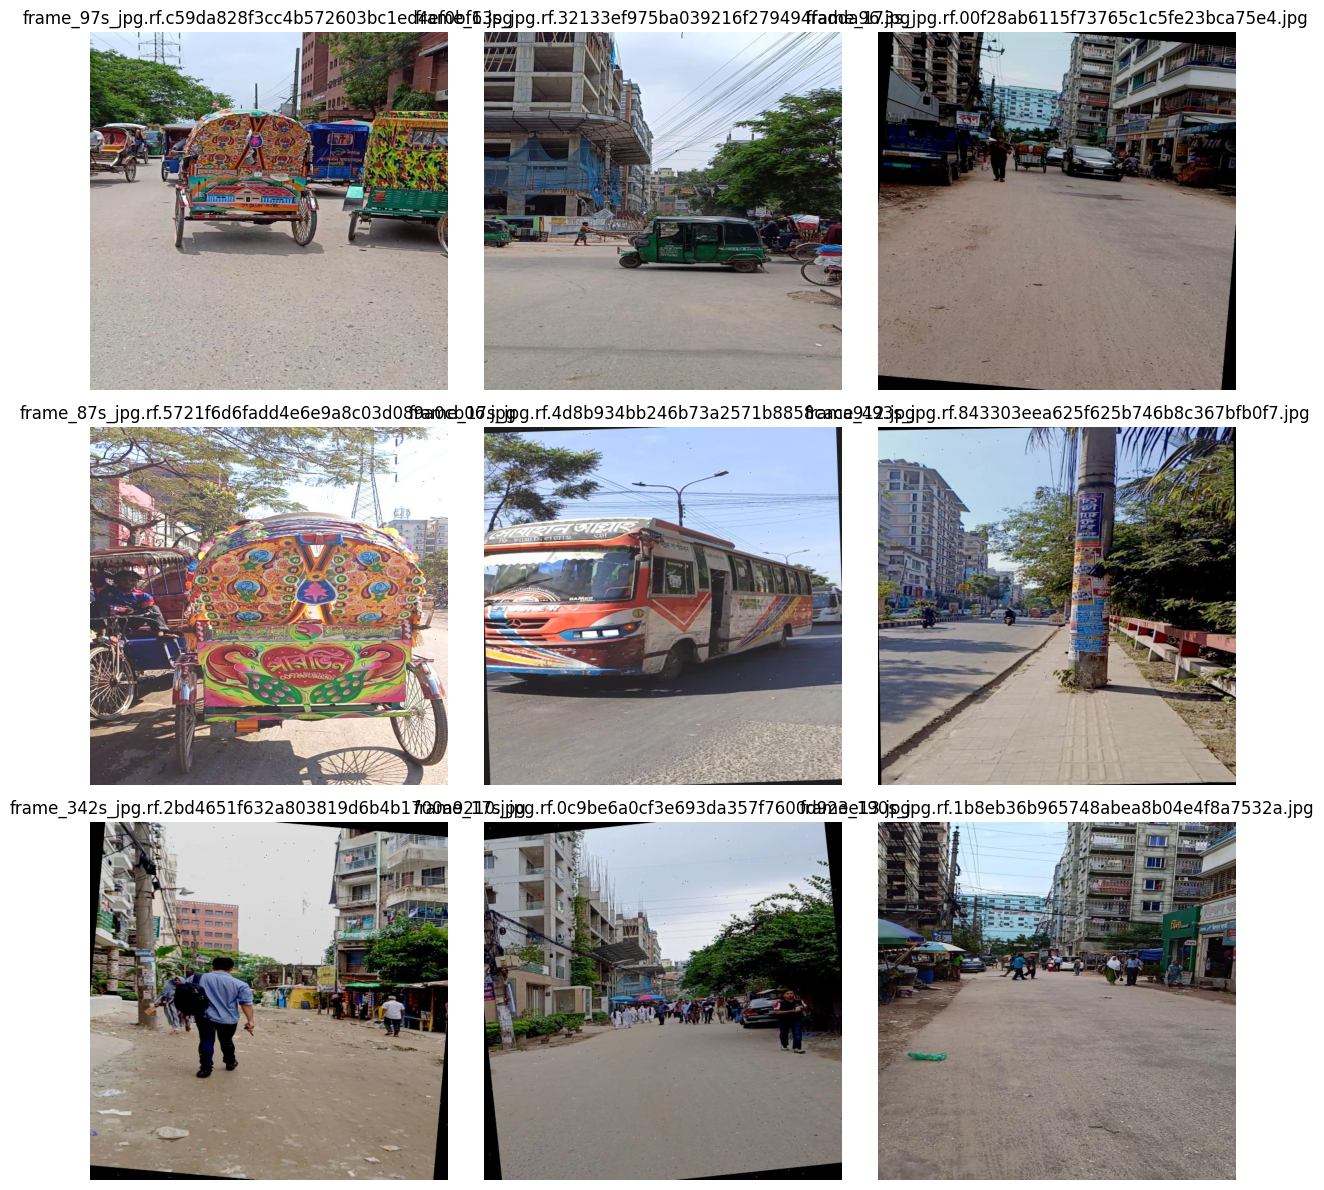

In [27]:
def show_samples(split="train", n=9):

    files = list((IMG_OUT / split).glob("*"))
    random.shuffle(files)
    files = files[:n]

    cols = 3
    grid_rows = (len(files) + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * grid_rows))

    for i, img_path in enumerate(files):

        img = cv2.imread(str(img_path))

        if img is None:
            print(f"[WARNING] Could not read image: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = LBL_OUT / split / f"{img_path.stem}.txt"

        if lbl_path.exists():

            for line_num, line in enumerate(
                lbl_path.read_text().splitlines(), start=1
            ):

                if not line.strip():
                    continue

                parts = line.split()

                # YOLO format must contain exactly 5 values
                if len(parts) != 5:
                    print(
                        f"[SKIP] {lbl_path.name} | "
                        f"line {line_num} | "
                        f"found {len(parts)} values"
                    )
                    print("       ", line)
                    continue

                try:
                    cid, xc, yc, bw, bh = map(float, parts)

                    cid = int(cid)

                    # Check class ID
                    if cid < 0 or cid >= len(CLASS_NAMES):
                        print(
                            f"[SKIP] Invalid class ID {cid} "
                            f"in {lbl_path.name}, line {line_num}"
                        )
                        continue

                    # Convert YOLO normalized coordinates to pixels
                    x1 = int((xc - bw / 2) * w)
                    y1 = int((yc - bh / 2) * h)
                    x2 = int((xc + bw / 2) * w)
                    y2 = int((yc + bh / 2) * h)

                    # Keep coordinates inside image
                    x1 = max(0, min(x1, w - 1))
                    y1 = max(0, min(y1, h - 1))
                    x2 = max(0, min(x2, w - 1))
                    y2 = max(0, min(y2, h - 1))

                    cv2.rectangle(
                        img,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )

                    cv2.putText(
                        img,
                        CLASS_NAMES[cid],
                        (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )

                except ValueError:
                    print(
                        f"[SKIP] Non-numeric annotation: "
                        f"{lbl_path.name}, line {line_num}"
                    )
                    print("       ", line)

        plt.subplot(grid_rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()


show_samples("train", n=9)

## 6. Train YOLO11n




In [28]:
from ultralytics import YOLO

IMGSZ = 320
EPOCHS = 80
BATCH = 16

model = YOLO("yolo11n.pt")

train_results = model.train(
    data=DATA_YAML_PATH,
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH,
    patience=20,
    project="runs/blind_assist",
    name="yolo11n_run1",
    device=0 if torch.cuda.is_available() else "cpu",
)

run_dir = Path(model.trainer.save_dir)
print("Run saved to:", run_dir)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0,

## 7. Post-training evaluation


In [29]:
metrics = model.val()
print("mAP50:   ", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("\nPer-class AP50-95:")
for i, ap in enumerate(metrics.box.maps):
    print(f"  {CLASS_NAMES[i]:20s} {ap:.3f}")


Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,586,442 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1793.6±813.5 MB/s, size: 75.0 KB)
val: Scanning /content/dataset_yolo/labels/val.cache... 702 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 702/702 184.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 7.1it/s 6.2s
                   all        702       2913      0.882      0.868      0.924      0.763
                   Bin          4          4          1      0.363      0.745      0.596
       Building Pillar         20         56      0.856      0.929      0.955      0.758
                   Bus         68         72      0.897          1      0.983      0.919
                   CNG         86         97       0.87      0.938      0.953      0.828
                   Car        208        

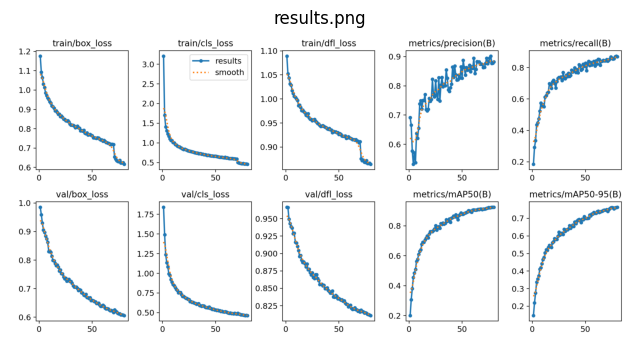

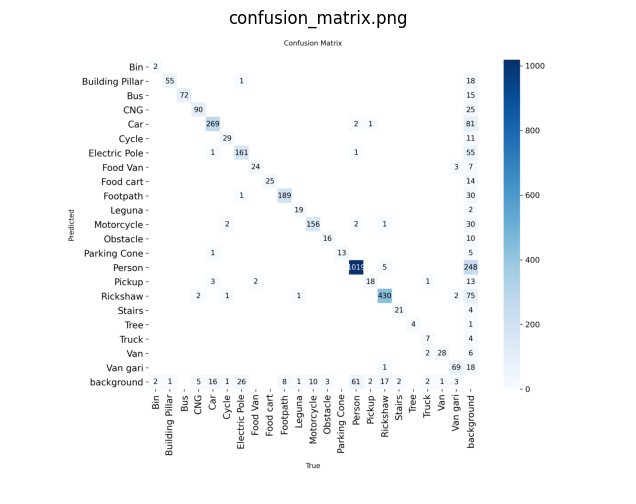

In [30]:
for name in ["results.png", "confusion_matrix.png", "PR_curve.png"]:
    p = run_dir / name
    if p.exists():
        img = Image.open(p)
        plt.figure(figsize=(8, 6))
        plt.imshow(img); plt.axis("off"); plt.title(name)
        plt.show()


### Inference on a few validation images



0: 320x320 1 Bus, 1 CNG, 1 Electric Pole, 1 Footpath, 1 Person, 1.8ms
1: 320x320 1 Electric Pole, 1 Footpath, 1 Truck, 1.8ms
2: 320x320 1 CNG, 1 Person, 3 Rickshaws, 1.8ms
3: 320x320 1 CNG, 1 Car, 2 Motorcycles, 1 Person, 1 Rickshaw, 1.8ms
4: 320x320 1 Motorcycle, 10 Persons, 1.8ms
5: 320x320 1 Electric Pole, 1 Food Van, 4 Persons, 1.8ms
Speed: 0.7ms preprocess, 1.8ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)


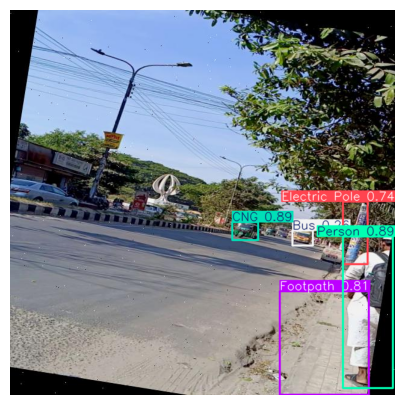

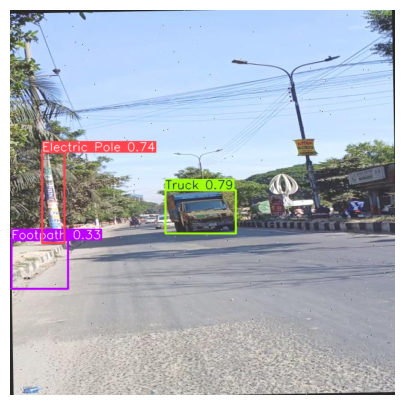

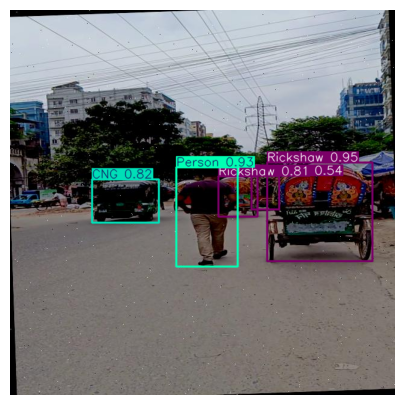

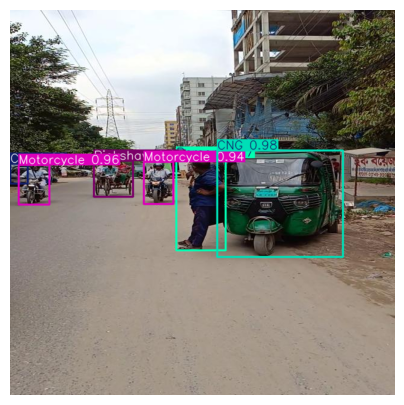

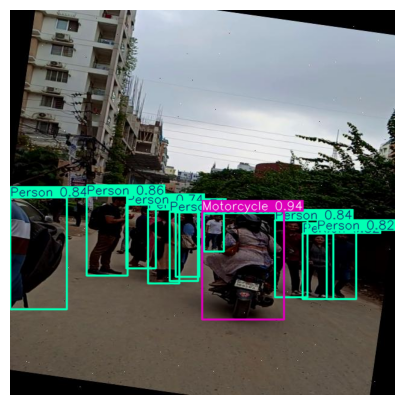

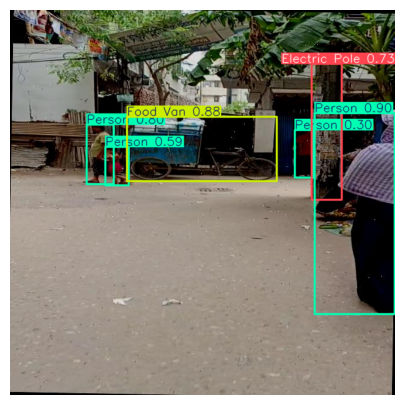

In [31]:
val_imgs = list((IMG_OUT / "val").glob("*"))[:6]
pred_results = model.predict(source=[str(p) for p in val_imgs], imgsz=IMGSZ, conf=0.25)

for r in pred_results:
    plt.figure(figsize=(5, 5))
    plt.imshow(r.plot()[:, :, ::-1])
    plt.axis("off")
    plt.show()


## 8. Export for ESP32-S3-CAM deployment

- **ONNX** — portable, easy to inspect/debug on a PC.
- **INT8 TFLite** — this is the format you actually want on-device. It uses a
  calibration pass over your training images, so quality depends on how
  representative that data is of what the camera will actually see.




In [32]:
model.export(format="onnx", imgsz=IMGSZ, simplify=True)

model.export(format="tflite", imgsz=IMGSZ, int8=True, data=DATA_YAML_PATH)

print("\nExported files:")
for f in (run_dir / "weights").glob("*"):
    print(" ", f)


Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino

PyTorch: starting from '/content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 26, 2100) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 335ms
Prepared 4 packages in 1.91s
Installed 4 packages in 267ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 4.9s, saved 

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [START] Write Model to /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite

(00:00) [ DONE] Write Model to /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite 
(+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.13/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 572/572 [00:00<00:00, 14491.42it/s]


Model name: /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite
Original model size: 10.08 MiB
Quantized model size: 2.89 MiB
Quantization Ratio: 0.29 (3.5x smaller)
Total time: 331.82 ms
LiteRT: export success ✅ 214.1s, saved as '/content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite' (2.9 MB)

Export complete (214.2s)
Results saved to /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best_int8.tflite imgsz=320 data=/content/dataset_yolo/data.yaml  
Visualize:       https://netron.app

Exported files:
  /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best.pt
  /content/runs/detect/runs/blind_assist/yolo11n_run1/weights/best.onnx
  /content/runs/detect/runs/blind_as

## 9. Download everything


In [33]:
shutil.make_archive("/content/training_outputs", "zip", run_dir)

from google.colab import files
files.download("/content/training_outputs.zip")

for f in (run_dir / "weights").glob("*"):
    files.download(str(f))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>